# A Hybrid CNN-BiLSTM Framework with Attention Mechanism for Cardiovascular Disease Prediction

**Pipeline order (reversed from the earlier version):**
1. **Primary dataset: Kaggle Cardiovascular Disease (~70k rows)** — full pipeline: EDA,
   preprocessing, training, evaluation, 10-fold CV, ablation study.
2. **Secondary/validation dataset: UCI Cleveland Heart Disease (303 rows)** — same pipeline,
   run second, to check whether conclusions from the large dataset hold up on the smaller,
   more clinically-curated one.
3. **Cross-dataset comparison**, including the pooling-vs-attention grid, at the end.

Model definitions and training/evaluation helper functions are defined once and reused for
both datasets, so the two runs are directly comparable.


## 1. Data Sources

- **Primary — Kaggle Cardiovascular Disease dataset (~70,000 rows, 11 features):**
  https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset
  (pulled via `kagglehub`, not a manual upload)
- **Secondary — UCI Heart Disease (Cleveland), id=45 (303 rows, 13 features):**
  https://archive.ics.uci.edu/dataset/45/heart+disease · DOI: https://doi.org/10.24432/C52P4X
  (pulled via `ucimlrepo`)


## 2. Install dependencies

In [1]:
!pip install -q ucimlrepo kagglehub torch pandas numpy scikit-learn imbalanced-learn matplotlib seaborn

## 3. Imports and shared setup

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
print("Using device:", device)

Using device: cuda


## 4. Model Definitions (shared across both datasets)

- **1D-CNN + BatchNorm + MaxPool**: local feature combinations.
- **BiLSTM**: forward/backward context over the CNN's feature map.
- **Attention layer**: learns which positions matter most; returns weights for visualization.
- **`use_pooling` toggle**: lets us test whether attention benefits from seeing the
  full-length sequence instead of a pooled/shortened one (used later in the pooling grid).


In [3]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)

    def forward(self, rnn_output):
        scores = self.attn(rnn_output)
        alpha = torch.softmax(scores, dim=1)
        context = torch.sum(alpha * rnn_output, dim=1)
        return context, alpha


class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, num_features, cnn_channels=16, lstm_hidden=32, dropout=0.3, use_pooling=True):
        super().__init__()
        self.conv1 = nn.Conv1d(1, cnn_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(cnn_channels)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=1) if use_pooling else nn.Identity()
        self.dropout1 = nn.Dropout(dropout)
        self.bilstm = nn.LSTM(cnn_channels, lstm_hidden, batch_first=True, bidirectional=True)
        self.attention = Attention(hidden_size=lstm_hidden * 2)
        self.dropout2 = nn.Dropout(dropout)
        self.fc1 = nn.Linear(lstm_hidden * 2, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.dropout1(self.pool(self.relu(self.bn1(self.conv1(x)))))
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.bilstm(x)
        context, attn_weights = self.attention(lstm_out)
        x = self.relu(self.fc1(self.dropout2(context)))
        return self.fc2(x), attn_weights


class CNN_BiLSTM_NoAttention(nn.Module):
    def __init__(self, num_features, cnn_channels=16, lstm_hidden=32, dropout=0.3, use_pooling=True):
        super().__init__()
        self.conv1 = nn.Conv1d(1, cnn_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(cnn_channels)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=1) if use_pooling else nn.Identity()
        self.dropout = nn.Dropout(dropout)
        self.bilstm = nn.LSTM(cnn_channels, lstm_hidden, batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(lstm_hidden * 2, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.dropout(self.pool(self.relu(self.bn1(self.conv1(x)))))
        x = x.permute(0, 2, 1)
        out, (h_n, _) = self.bilstm(x)
        last = torch.cat([h_n[0], h_n[1]], dim=1)
        x = self.relu(self.fc1(last))
        return self.fc2(x), None


class CNNOnly(nn.Module):
    def __init__(self, num_features, cnn_channels=16, dropout=0.3, use_pooling=True):
        super().__init__()
        self.conv1 = nn.Conv1d(1, cnn_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(cnn_channels)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=1) if use_pooling else nn.Identity()
        self.dropout = nn.Dropout(dropout)
        self.flatten = nn.Flatten()
        pooled_len = ((num_features + 2 * 1 - 2) // 2 + 1) if use_pooling else num_features
        self.fc1 = nn.Linear(cnn_channels * pooled_len, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.dropout(self.pool(self.relu(self.bn1(self.conv1(x)))))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x), None

## 5. Shared Helper Functions

These are dataset-agnostic, so the exact same code trains/evaluates both the Kaggle and the
UCI runs below - only the input `X`/`y` change.

In [4]:
def to_tensors(X_arr, y_arr):
    X_t = torch.tensor(np.asarray(X_arr), dtype=torch.float32).unsqueeze(1)
    y_vals = y_arr.values if hasattr(y_arr, "values") else y_arr
    y_t = torch.tensor(np.asarray(y_vals), dtype=torch.float32).unsqueeze(1)
    return X_t, y_t


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if is_train:
                optimizer.zero_grad()
            preds, _ = model(xb)
            loss = criterion(preds, yb)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            pred_cls = (torch.sigmoid(preds) >= 0.5).float()
            correct += (pred_cls == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


def preprocess_and_split(X, y, test_size=0.2, use_imputation=None):
    """Stratified split -> (KNN impute if needed) -> scale (fit on train only) -> SMOTE (train only)."""
    X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=SEED, stratify=y
    )
    if use_imputation is None:
        use_imputation = X.isna().any().any()

    if use_imputation:
        imp = KNNImputer(n_neighbors=5)
        X_tr_i = imp.fit_transform(X_tr_raw)
        X_te_i = imp.transform(X_te_raw)
    else:
        X_tr_i, X_te_i = X_tr_raw.values, X_te_raw.values

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr_i)
    X_te_s = sc.transform(X_te_i)

    print("Class balance before SMOTE:", np.bincount(y_tr))
    X_tr_r, y_tr_r = SMOTE(random_state=SEED).fit_resample(X_tr_s, y_tr)
    print("Class balance after SMOTE: ", np.bincount(y_tr_r))

    return X_tr_r, y_tr_r, X_te_s, y_te


def make_loaders(X_tr_r, y_tr_r, X_te_s, y_te, batch_size=BATCH_SIZE):
    Xt, yt = to_tensors(X_tr_r, y_tr_r)
    Xv, yv = to_tensors(X_te_s, y_te)
    train_loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(Xv, yv), batch_size=batch_size, shuffle=False)
    return train_loader, test_loader, Xt.shape[2]


def train_model(model_cls, train_loader, test_loader, num_features, epochs=60,
                 patience_limit=10, label="model", use_pooling=True):
    model = model_cls(num_features=num_features, use_pooling=use_pooling).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss, best_state, patience = float("inf"), None, 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, test_loader, criterion, optimizer=None)
        scheduler.step(val_loss)
        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1

        if epoch % max(1, epochs // 10) == 0 or epoch == 1:
            print(f"[{label}] Epoch {epoch:03d}/{epochs} | train_loss={tr_loss:.4f} "
                  f"train_acc={tr_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if patience >= patience_limit:
            print(f"[{label}] Early stopping at epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def evaluate_model(model, test_loader, label="model", save_prefix=None, plot=True):
    model.eval()
    all_probs, all_true, all_attn = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds, attn = model(xb.to(device))
            all_probs.append(torch.sigmoid(preds).cpu().numpy())
            all_true.append(yb.numpy())
            if attn is not None:
                all_attn.append(attn.cpu().numpy())

    all_probs = np.concatenate(all_probs).ravel()
    all_true = np.concatenate(all_true).ravel()
    all_pred = (all_probs >= 0.5).astype(int)

    metrics = {
        "Accuracy": accuracy_score(all_true, all_pred),
        "Precision": precision_score(all_true, all_pred, zero_division=0),
        "Recall": recall_score(all_true, all_pred, zero_division=0),
        "F1": f1_score(all_true, all_pred, zero_division=0),
        "AUC": roc_auc_score(all_true, all_probs),
    }
    print(f"[{label}] " + "  ".join(f"{k}={v:.4f}" for k, v in metrics.items()))
    print(classification_report(all_true, all_pred, target_names=["No Disease", "Disease"]))

    if plot:
        cm = confusion_matrix(all_true, all_pred)
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"], ax=axes[0])
        axes[0].set_title(f"{label} - Confusion Matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
        fpr, tpr, _ = roc_curve(all_true, all_probs)
        axes[1].plot(fpr, tpr, label=f"AUC = {metrics['AUC']:.3f}", color="#C44E52")
        axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
        axes[1].set_title(f"{label} - ROC Curve"); axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
        axes[1].legend()
        plt.tight_layout()
        if save_prefix:
            plt.savefig(f"{save_prefix}_confusion_roc.png", dpi=300)
        plt.show()

    attn_all = np.concatenate(all_attn).squeeze(-1) if all_attn else None
    return metrics, attn_all


def cv_evaluate(X, y, model_cls, n_splits=10, epochs=60, use_pooling=True, label="model"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    X_np, y_np = X.reset_index(drop=True), y.reset_index(drop=True)
    accs, aucs, f1s = [], [], []
    use_imputation = X.isna().any().any()

    for tr_idx, va_idx in skf.split(X_np, y_np):
        X_tr, X_va = X_np.iloc[tr_idx], X_np.iloc[va_idx]
        y_tr, y_va = y_np.iloc[tr_idx], y_np.iloc[va_idx]

        if use_imputation:
            imp = KNNImputer(n_neighbors=5)
            X_tr_i, X_va_i = imp.fit_transform(X_tr), imp.transform(X_va)
        else:
            X_tr_i, X_va_i = X_tr.values, X_va.values

        sc = StandardScaler()
        X_tr_s, X_va_s = sc.fit_transform(X_tr_i), sc.transform(X_va_i)
        X_tr_r, y_tr_r = SMOTE(random_state=SEED).fit_resample(X_tr_s, y_tr)

        if model_cls is RandomForestClassifier:
            rf = RandomForestClassifier(n_estimators=300, random_state=SEED)
            rf.fit(X_tr_r, y_tr_r)
            preds = rf.predict(X_va_s)
            probs = rf.predict_proba(X_va_s)[:, 1]
        else:
            train_loader, test_loader, num_features = make_loaders(X_tr_r, y_tr_r, X_va_s, y_va)
            m, _ = train_model(model_cls, train_loader, test_loader, num_features,
                                epochs=epochs, patience_limit=epochs, label=label, use_pooling=use_pooling)
            m.eval()
            probs_l, trues_l = [], []
            with torch.no_grad():
                for xb, yb in test_loader:
                    p, _ = m(xb.to(device))
                    probs_l.append(torch.sigmoid(p).cpu().numpy())
                    trues_l.append(yb.numpy())
            probs = np.concatenate(probs_l).ravel()
            y_va = np.concatenate(trues_l).ravel()
            preds = (probs >= 0.5).astype(int)

        accs.append(accuracy_score(y_va, preds))
        aucs.append(roc_auc_score(y_va, probs) if len(np.unique(y_va)) > 1 else float("nan"))
        f1s.append(f1_score(y_va, preds, zero_division=0))

    return {
        "Accuracy (mean)": np.mean(accs), "Accuracy (std)": np.std(accs),
        "AUC (mean)": np.nanmean(aucs), "AUC (std)": np.nanstd(aucs),
        "F1 (mean)": np.mean(f1s), "F1 (std)": np.std(f1s),
    }

## 6. PRIMARY DATASET: Kaggle Cardiovascular Disease (~70k rows)

### 6.1 Load and clean

Loaded via `kagglehub` (a script call, not a manual upload). Known data-quality issues in this
dataset are cleaned here: `age` is in days (converted to years), and `ap_hi`/`ap_lo` (blood
pressure) contain physically impossible values from self-reporting.

In [5]:
!pip install -q kagglehub
import kagglehub

kaggle_path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")
csv_name = [f for f in os.listdir(kaggle_path) if f.endswith(".csv")][0]
df_cardio_raw = pd.read_csv(os.path.join(kaggle_path, csv_name), sep=";")
print("Raw shape:", df_cardio_raw.shape)
df_cardio_raw.head()

Using Colab cache for faster access to the 'cardiovascular-disease-dataset' dataset.
Raw shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [6]:
df_c = df_cardio_raw.copy()
df_c["age_years"] = (df_c["age"] / 365.25).round(1)

df_c = df_c[
    (df_c["ap_hi"].between(70, 250)) &
    (df_c["ap_lo"].between(40, 150)) &
    (df_c["ap_hi"] > df_c["ap_lo"])
]
for col in ["height", "weight"]:
    lo, hi = df_c[col].quantile([0.005, 0.995])
    df_c = df_c[df_c[col].between(lo, hi)]

print(f"Rows after cleaning: {len(df_c)} (dropped {len(df_cardio_raw) - len(df_c)} of {len(df_cardio_raw)})")

feature_cols = ["age_years", "gender", "height", "weight", "ap_hi", "ap_lo",
                 "cholesterol", "gluc", "smoke", "alco", "active"]
X_kaggle = df_c[feature_cols].reset_index(drop=True)
y_kaggle = df_c["cardio"].reset_index(drop=True)
print("Cleaned shape:", X_kaggle.shape, " Class balance:", np.bincount(y_kaggle))
X_kaggle.head()

Rows after cleaning: 67538 (dropped 2462 of 70000)
Cleaned shape: (67538, 11)  Class balance: [34153 33385]


,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
0,50.4,2,168,62.0,110,80,1,1,0,0,1
1,55.4,1,156,85.0,140,90,3,1,0,0,1
2,51.6,1,165,64.0,130,70,3,1,0,0,0
3,48.2,2,169,82.0,150,100,1,1,0,0,1
4,47.8,1,156,56.0,100,60,1,1,0,0,0


### 6.2 EDA

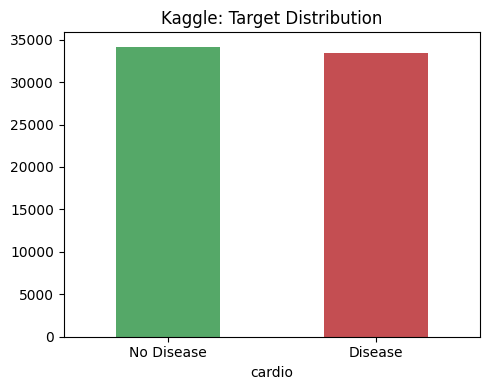

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
pd.Series(y_kaggle).value_counts().sort_index().plot(kind="bar", ax=ax, color=["#55A868", "#C44E52"])
ax.set_xticklabels(["No Disease", "Disease"], rotation=0)
ax.set_title("Kaggle: Target Distribution")
plt.tight_layout()
plt.savefig("kaggle_class_distribution.png", dpi=300)
plt.show()

### 6.3 Preprocessing (split -> scale -> SMOTE)

In [8]:
X_tr_r_k, y_tr_r_k, X_te_s_k, y_te_k = preprocess_and_split(X_kaggle, y_kaggle)
train_loader_k, test_loader_k, num_features_k = make_loaders(X_tr_r_k, y_tr_r_k, X_te_s_k, y_te_k)

Class balance before SMOTE: [27322 26708]
Class balance after SMOTE:  [27322 27322]


### 6.4 Train the proposed CNN-BiLSTM+Attention model

[Kaggle-Attention] Epoch 001/25 | train_loss=0.5999 train_acc=0.6882 | val_loss=0.5711 val_acc=0.7131
[Kaggle-Attention] Epoch 002/25 | train_loss=0.5776 train_acc=0.7075 | val_loss=0.5623 val_acc=0.7184
[Kaggle-Attention] Epoch 004/25 | train_loss=0.5657 train_acc=0.7188 | val_loss=0.5550 val_acc=0.7254
[Kaggle-Attention] Epoch 006/25 | train_loss=0.5588 train_acc=0.7227 | val_loss=0.5514 val_acc=0.7272
[Kaggle-Attention] Epoch 008/25 | train_loss=0.5563 train_acc=0.7247 | val_loss=0.5501 val_acc=0.7285
[Kaggle-Attention] Epoch 010/25 | train_loss=0.5566 train_acc=0.7251 | val_loss=0.5479 val_acc=0.7298
[Kaggle-Attention] Epoch 012/25 | train_loss=0.5551 train_acc=0.7259 | val_loss=0.5537 val_acc=0.7282
[Kaggle-Attention] Early stopping at epoch 12.


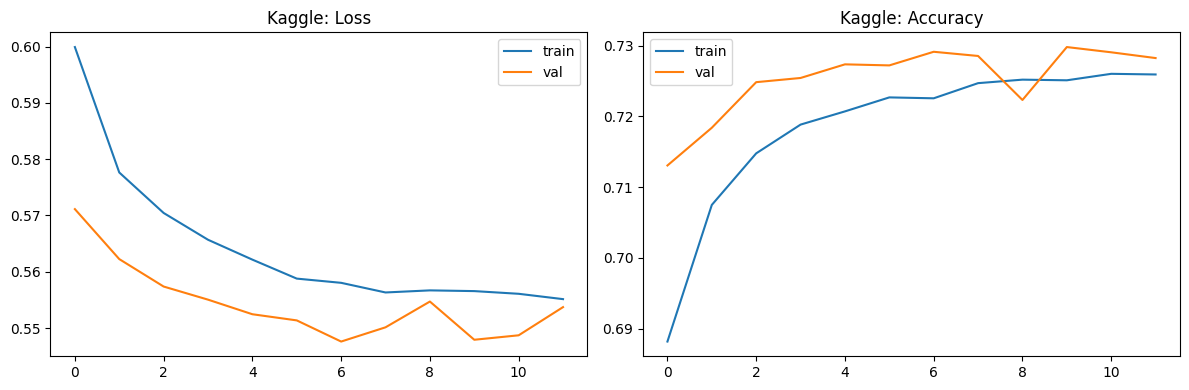

In [9]:
model_k, history_k = train_model(
    CNN_BiLSTM_Attention, train_loader_k, test_loader_k, num_features_k,
    epochs=25, patience_limit=5, label="Kaggle-Attention"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_k["train_loss"], label="train"); axes[0].plot(history_k["val_loss"], label="val")
axes[0].set_title("Kaggle: Loss"); axes[0].legend()
axes[1].plot(history_k["train_acc"], label="train"); axes[1].plot(history_k["val_acc"], label="val")
axes[1].set_title("Kaggle: Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig("kaggle_training_curves.png", dpi=300)
plt.show()

### 6.5 Evaluate on held-out test set

[Kaggle] Accuracy=0.7291  Precision=0.7641  Recall=0.6539  F1=0.7047  AUC=0.7953
              precision    recall  f1-score   support

  No Disease       0.70      0.80      0.75      6831
     Disease       0.76      0.65      0.70      6677

    accuracy                           0.73     13508
   macro avg       0.73      0.73      0.73     13508
weighted avg       0.73      0.73      0.73     13508



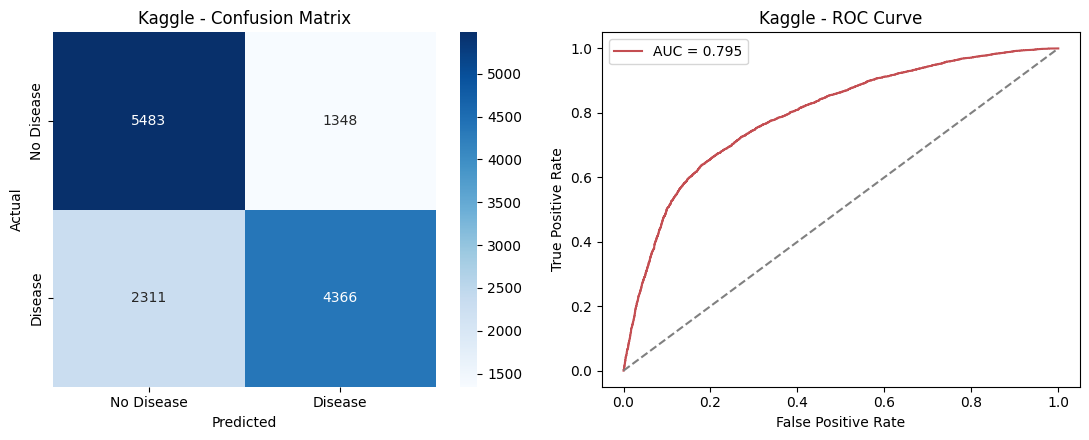

In [10]:
kaggle_metrics, kaggle_attn = evaluate_model(model_k, test_loader_k, label="Kaggle", save_prefix="kaggle")

### 6.6 Attention weights (Kaggle)

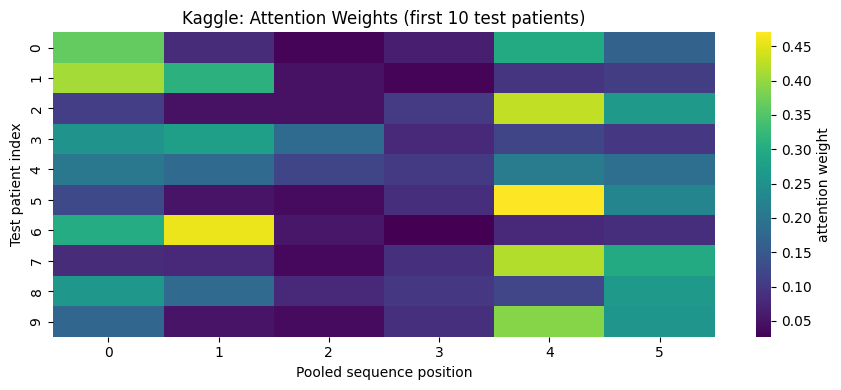

In [11]:
if kaggle_attn is not None:
    n_show = min(10, kaggle_attn.shape[0])
    plt.figure(figsize=(9, 4))
    sns.heatmap(kaggle_attn[:n_show], cmap="viridis", cbar_kws={"label": "attention weight"})
    plt.title(f"Kaggle: Attention Weights (first {n_show} test patients)")
    plt.xlabel("Pooled sequence position"); plt.ylabel("Test patient index")
    plt.tight_layout()
    plt.savefig("kaggle_attention_weights.png", dpi=300)
    plt.show()

### 6.7 10-fold CV and ablation study (Kaggle)

Fewer folds/epochs than you'd use for the final paper numbers, since this is 70k rows per
fold — raise both once you've confirmed the cell runs end-to-end.

In [12]:
kaggle_model_classes = {
    "Random Forest": RandomForestClassifier,
    "1D-CNN only": CNNOnly,
    "CNN-BiLSTM (no attention)": CNN_BiLSTM_NoAttention,
    "CNN-BiLSTM + Attention (proposed)": CNN_BiLSTM_Attention,
}

kaggle_cv_results = {}
for name, cls in kaggle_model_classes.items():
    kaggle_cv_results[name] = cv_evaluate(X_kaggle, y_kaggle, cls, n_splits=5, epochs=15, label=f"Kaggle-{name}")

kaggle_cv_df = pd.DataFrame(kaggle_cv_results).T.round(4)
kaggle_cv_df.to_csv("kaggle_cv_results.csv")
kaggle_cv_df

[Kaggle-1D-CNN only] Epoch 001/15 | train_loss=0.5678 train_acc=0.7190 | val_loss=0.5533 val_acc=0.7238
[Kaggle-1D-CNN only] Epoch 002/15 | train_loss=0.5606 train_acc=0.7221 | val_loss=0.5484 val_acc=0.7290
[Kaggle-1D-CNN only] Epoch 003/15 | train_loss=0.5582 train_acc=0.7237 | val_loss=0.5472 val_acc=0.7289
[Kaggle-1D-CNN only] Epoch 004/15 | train_loss=0.5568 train_acc=0.7260 | val_loss=0.5476 val_acc=0.7300
[Kaggle-1D-CNN only] Epoch 005/15 | train_loss=0.5564 train_acc=0.7265 | val_loss=0.5501 val_acc=0.7316
[Kaggle-1D-CNN only] Epoch 006/15 | train_loss=0.5563 train_acc=0.7267 | val_loss=0.5476 val_acc=0.7283
[Kaggle-1D-CNN only] Epoch 007/15 | train_loss=0.5554 train_acc=0.7245 | val_loss=0.5451 val_acc=0.7333
[Kaggle-1D-CNN only] Epoch 008/15 | train_loss=0.5553 train_acc=0.7256 | val_loss=0.5455 val_acc=0.7325
[Kaggle-1D-CNN only] Epoch 009/15 | train_loss=0.5542 train_acc=0.7271 | val_loss=0.5445 val_acc=0.7321
[Kaggle-1D-CNN only] Epoch 010/15 | train_loss=0.5542 train_acc=

,Accuracy (mean),Accuracy (std),AUC (mean),AUC (std),F1 (mean),F1 (std)
Random Forest,0.7121,0.0032,0.7730,0.0022,0.7058,0.0024
1D-CNN only,0.7332,0.0014,0.7982,0.0022,0.7191,0.0028
CNN-BiLSTM (no attention),0.7330,0.0018,0.7982,0.0019,0.7164,0.0048
CNN-BiLSTM + Attention (proposed),0.7319,0.0026,0.7976,0.0023,0.7132,0.0037


## 7. SECONDARY / VALIDATION DATASET: UCI Cleveland (303 rows)

Same pipeline, run second, using the exact same model classes and helper functions above —
so any difference in outcome is about the data, not the code.

### 7.1 Load

In [13]:
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)
X_uci = heart_disease.data.features
y_raw_full = heart_disease.data.targets

print(heart_disease.metadata)
print(heart_disease.variables)

y_raw_uci = y_raw_full.iloc[:, 0] if hasattr(y_raw_full, "iloc") and y_raw_full.ndim > 1 else y_raw_full.squeeze()
y_uci = (y_raw_uci > 0).astype(int)
print("\nFeature matrix shape:", X_uci.shape, " Class balance:", np.bincount(y_uci))
X_uci.head()

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


### 7.2 Preprocessing (KNN-impute -> split -> scale -> SMOTE)

In [14]:
print("Missing values per column:\n", X_uci.isna().sum())
X_tr_r_u, y_tr_r_u, X_te_s_u, y_te_u = preprocess_and_split(X_uci, y_uci)
train_loader_u, test_loader_u, num_features_u = make_loaders(X_tr_r_u, y_tr_r_u, X_te_s_u, y_te_u)

Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64
Class balance before SMOTE: [131 111]
Class balance after SMOTE:  [131 131]


### 7.3 Train the proposed model

[UCI-Attention] Epoch 001/100 | train_loss=0.6841 train_acc=0.6374 | val_loss=0.6769 val_acc=0.7541
[UCI-Attention] Epoch 010/100 | train_loss=0.4613 train_acc=0.8092 | val_loss=0.4006 val_acc=0.8525
[UCI-Attention] Epoch 020/100 | train_loss=0.4214 train_acc=0.8244 | val_loss=0.4066 val_acc=0.8361
[UCI-Attention] Epoch 030/100 | train_loss=0.4524 train_acc=0.7939 | val_loss=0.3765 val_acc=0.8361
[UCI-Attention] Epoch 040/100 | train_loss=0.4204 train_acc=0.8053 | val_loss=0.3628 val_acc=0.8361
[UCI-Attention] Epoch 050/100 | train_loss=0.3963 train_acc=0.8130 | val_loss=0.3500 val_acc=0.8689
[UCI-Attention] Epoch 060/100 | train_loss=0.4217 train_acc=0.7977 | val_loss=0.3569 val_acc=0.8361
[UCI-Attention] Epoch 070/100 | train_loss=0.4145 train_acc=0.7977 | val_loss=0.3613 val_acc=0.8361
[UCI-Attention] Early stopping at epoch 77.


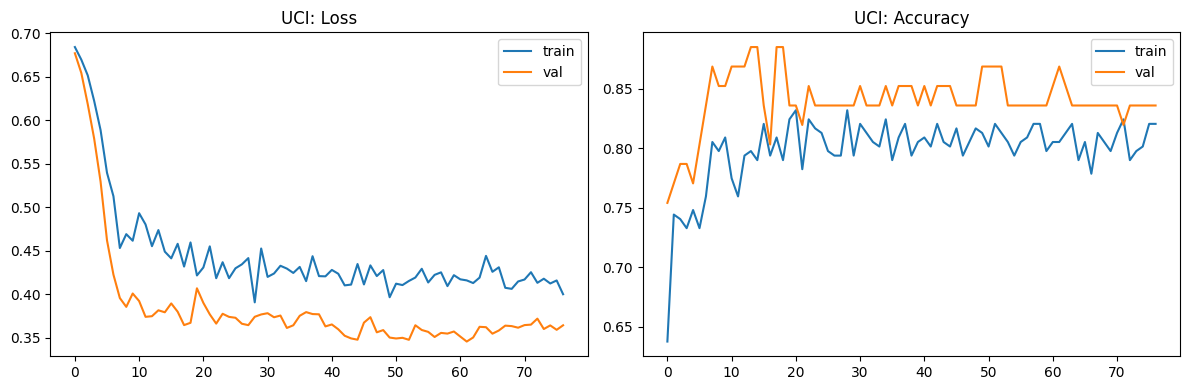

In [15]:
model_u, history_u = train_model(
    CNN_BiLSTM_Attention, train_loader_u, test_loader_u, num_features_u,
    epochs=100, patience_limit=15, label="UCI-Attention"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_u["train_loss"], label="train"); axes[0].plot(history_u["val_loss"], label="val")
axes[0].set_title("UCI: Loss"); axes[0].legend()
axes[1].plot(history_u["train_acc"], label="train"); axes[1].plot(history_u["val_acc"], label="val")
axes[1].set_title("UCI: Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig("uci_training_curves.png", dpi=300)
plt.show()

### 7.4 Evaluate on held-out test set

[UCI] Accuracy=0.8689  Precision=0.8571  Recall=0.8571  F1=0.8571  AUC=0.9361
              precision    recall  f1-score   support

  No Disease       0.88      0.88      0.88        33
     Disease       0.86      0.86      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



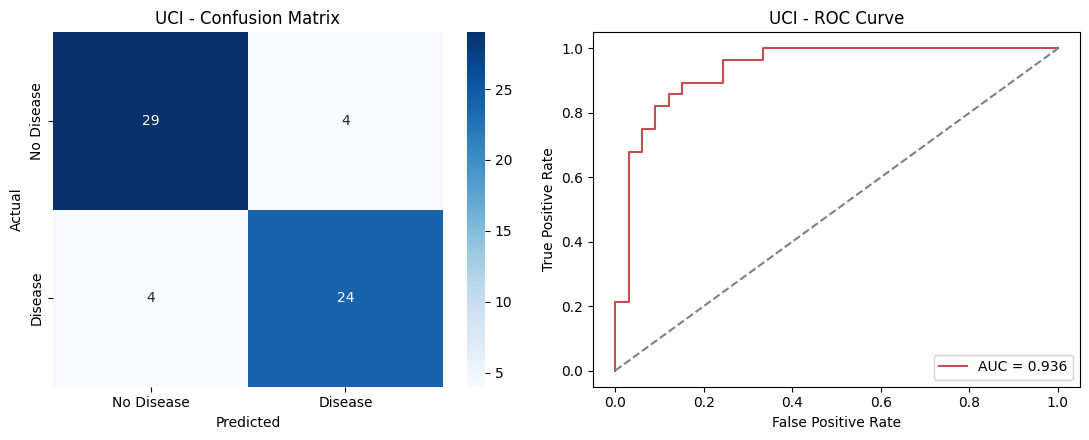

In [16]:
uci_metrics, uci_attn = evaluate_model(model_u, test_loader_u, label="UCI", save_prefix="uci")

### 7.5 Attention weights (UCI)

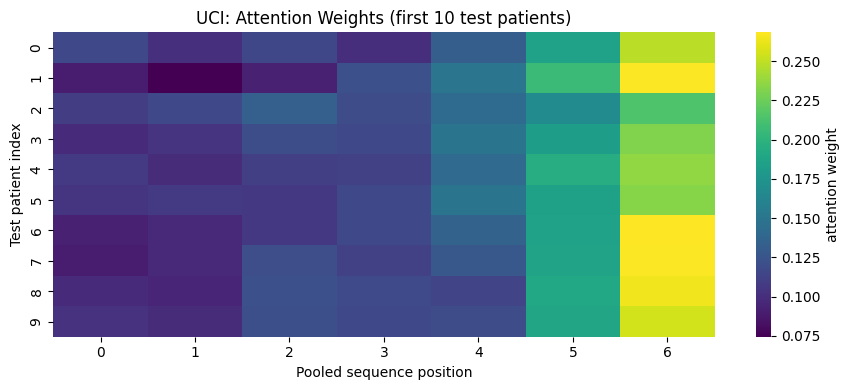

In [17]:
if uci_attn is not None:
    n_show = min(10, uci_attn.shape[0])
    plt.figure(figsize=(9, 4))
    sns.heatmap(uci_attn[:n_show], cmap="viridis", cbar_kws={"label": "attention weight"})
    plt.title(f"UCI: Attention Weights (first {n_show} test patients)")
    plt.xlabel("Pooled sequence position"); plt.ylabel("Test patient index")
    plt.tight_layout()
    plt.savefig("uci_attention_weights.png", dpi=300)
    plt.show()

### 7.6 10-fold CV and ablation study (UCI)

In [18]:
uci_model_classes = {
    "Random Forest": RandomForestClassifier,
    "1D-CNN only": CNNOnly,
    "CNN-BiLSTM (no attention)": CNN_BiLSTM_NoAttention,
    "CNN-BiLSTM + Attention (proposed)": CNN_BiLSTM_Attention,
}

uci_cv_results = {}
for name, cls in uci_model_classes.items():
    uci_cv_results[name] = cv_evaluate(X_uci, y_uci, cls, n_splits=10, epochs=60, label=f"UCI-{name}")

uci_cv_df = pd.DataFrame(uci_cv_results).T.round(4)
uci_cv_df.to_csv("uci_cv_results.csv")
uci_cv_df

[UCI-1D-CNN only] Epoch 001/60 | train_loss=0.6661 train_acc=0.6088 | val_loss=0.6449 val_acc=0.8065
[UCI-1D-CNN only] Epoch 006/60 | train_loss=0.3875 train_acc=0.8265 | val_loss=0.4483 val_acc=0.8387
[UCI-1D-CNN only] Epoch 012/60 | train_loss=0.3667 train_acc=0.8435 | val_loss=0.4459 val_acc=0.8387
[UCI-1D-CNN only] Epoch 018/60 | train_loss=0.3553 train_acc=0.8299 | val_loss=0.4183 val_acc=0.8387
[UCI-1D-CNN only] Epoch 024/60 | train_loss=0.3499 train_acc=0.8435 | val_loss=0.4242 val_acc=0.8387
[UCI-1D-CNN only] Epoch 030/60 | train_loss=0.3408 train_acc=0.8231 | val_loss=0.4154 val_acc=0.8710
[UCI-1D-CNN only] Epoch 036/60 | train_loss=0.3252 train_acc=0.8673 | val_loss=0.4216 val_acc=0.8387
[UCI-1D-CNN only] Epoch 042/60 | train_loss=0.3199 train_acc=0.8741 | val_loss=0.4251 val_acc=0.8387
[UCI-1D-CNN only] Epoch 048/60 | train_loss=0.3355 train_acc=0.8571 | val_loss=0.4238 val_acc=0.8387
[UCI-1D-CNN only] Epoch 054/60 | train_loss=0.3350 train_acc=0.8605 | val_loss=0.4220 val_a

,Accuracy (mean),Accuracy (std),AUC (mean),AUC (std),F1 (mean),F1 (std)
Random Forest,0.8314,0.0570,0.9044,0.0467,0.8110,0.0676
1D-CNN only,0.8315,0.0571,0.9071,0.0516,0.8082,0.0671
CNN-BiLSTM (no attention),0.8147,0.0567,0.9052,0.0341,0.7926,0.0589
CNN-BiLSTM + Attention (proposed),0.8313,0.0605,0.8993,0.0436,0.8056,0.0768


## 8. Cross-Dataset Comparison

Side-by-side single-split metrics (Sections 6.5 and 7.4) and the two ablation/CV tables.
This is the direct evidence for whether the proposed model's ranking against Random Forest
and against the no-attention baseline changes with dataset size.

In [19]:
cross_df = pd.DataFrame({"Kaggle (70k, primary)": kaggle_metrics, "UCI Cleveland (303, secondary)": uci_metrics}).round(4)
cross_df

,"Kaggle (70k, primary)","UCI Cleveland (303, secondary)"
Accuracy,0.7291,0.8689
Precision,0.7641,0.8571
Recall,0.6539,0.8571
F1,0.7047,0.8571
AUC,0.7953,0.9361


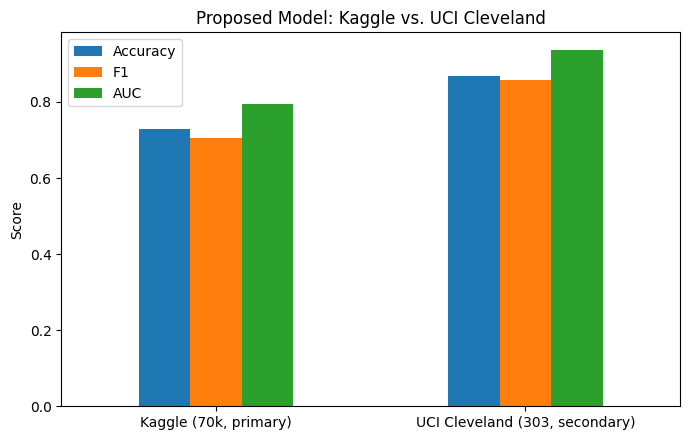

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5))
cross_df.T[["Accuracy", "F1", "AUC"]].plot(kind="bar", ax=ax)
ax.set_title("Proposed Model: Kaggle vs. UCI Cleveland")
ax.set_ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("cross_dataset_comparison.png", dpi=300)
plt.show()

## 9. Does Attention's Benefit Grow With Data and/or Less Pooling?

Trains attention vs. no-attention, pooled vs. unpooled, on both datasets, and reports
`attention accuracy - no-attention accuracy` for all four combinations. Kept fast
(few folds/epochs) — raise both for final paper numbers.

In [21]:
def run_cv_variant(X_data, y_data, model_ctor, n_splits=10, epochs=60):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    X_np, y_np = X_data.reset_index(drop=True), y_data.reset_index(drop=True)
    accs, aucs = [], []
    use_imputation = X_data.isna().any().any()
    for tr_idx, va_idx in skf.split(X_np, y_np):
        X_tr, X_va = X_np.iloc[tr_idx], X_np.iloc[va_idx]
        y_tr, y_va = y_np.iloc[tr_idx], y_np.iloc[va_idx]
        if use_imputation:
            imp = KNNImputer(n_neighbors=5)
            X_tr_i, X_va_i = imp.fit_transform(X_tr), imp.transform(X_va)
        else:
            X_tr_i, X_va_i = X_tr.values, X_va.values
        sc = StandardScaler()
        X_tr_s, X_va_s = sc.fit_transform(X_tr_i), sc.transform(X_va_i)
        X_tr_r, y_tr_r = SMOTE(random_state=SEED).fit_resample(X_tr_s, y_tr)
        train_loader, test_loader, nf = make_loaders(X_tr_r, y_tr_r, X_va_s, y_va)
        m = model_ctor(num_features=nf).to(device)
        opt = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
        crit = nn.BCEWithLogitsLoss()
        for _ in range(epochs):
            run_epoch(m, train_loader, crit, opt)
        m.eval()
        probs_l, trues_l = [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                p, _ = m(xb.to(device))
                probs_l.append(torch.sigmoid(p).cpu().numpy())
                trues_l.append(yb.numpy())
        probs = np.concatenate(probs_l).ravel()
        trues = np.concatenate(trues_l).ravel()
        preds = (probs >= 0.5).astype(int)
        accs.append(accuracy_score(trues, preds))
        aucs.append(roc_auc_score(trues, probs) if len(np.unique(trues)) > 1 else float("nan"))
    return np.mean(accs), np.nanmean(aucs)


# NOTE: epochs/n_splits are now set PER DATASET to match how long each one
# actually takes to converge (see Section 7's training curve for UCI - it
# needs ~40-60 epochs; Kaggle converges within ~10-15 given its size).
# Using a single flat epochs=10 for both previously under-trained UCI and
# produced identical pooled/unpooled accuracy - a sign of a near-constant
# classifier rather than a genuine architecture comparison.
dataset_cv_settings = {
    f"Kaggle ({len(X_kaggle)} rows)": {"X": X_kaggle, "y": y_kaggle, "n_splits": 5, "epochs": 15},
    f"UCI Cleveland ({len(X_uci)} rows)": {"X": X_uci, "y": y_uci, "n_splits": 10, "epochs": 60},
}
pooling_options = {"Pooled (aggressive)": True, "Unpooled (full sequence)": False}

grid_rows = []
for ds_name, cfg in dataset_cv_settings.items():
    Xd, yd, n_splits, epochs = cfg["X"], cfg["y"], cfg["n_splits"], cfg["epochs"]
    for pool_name, use_pool in pooling_options.items():
        acc_att, auc_att = run_cv_variant(
            Xd, yd, partial(CNN_BiLSTM_Attention, use_pooling=use_pool),
            n_splits=n_splits, epochs=epochs
        )
        acc_noatt, auc_noatt = run_cv_variant(
            Xd, yd, partial(CNN_BiLSTM_NoAttention, use_pooling=use_pool),
            n_splits=n_splits, epochs=epochs
        )
        grid_rows.append({
            "Dataset": ds_name, "Pooling": pool_name,
            "Attention Acc": round(acc_att, 4), "No-Attention Acc": round(acc_noatt, 4),
            "Attention Advantage (Acc)": round(acc_att - acc_noatt, 4),
            "Attention AUC": round(auc_att, 4), "No-Attention AUC": round(auc_noatt, 4),
            "Attention Advantage (AUC)": round(auc_att - auc_noatt, 4),
        })
        print(f"{ds_name} | {pool_name}: adv_acc={acc_att - acc_noatt:+.4f} adv_auc={auc_att - auc_noatt:+.4f}")

grid_df = pd.DataFrame(grid_rows)
grid_df.to_csv("attention_advantage_grid.csv", index=False)
grid_df

Kaggle (67538 rows) | Pooled (aggressive): adv_acc=-0.0009 adv_auc=-0.0012
Kaggle (67538 rows) | Unpooled (full sequence): adv_acc=+0.0002 adv_auc=+0.0006
UCI Cleveland (303 rows) | Pooled (aggressive): adv_acc=-0.0134 adv_auc=-0.0003
UCI Cleveland (303 rows) | Unpooled (full sequence): adv_acc=+0.0096 adv_auc=+0.0126


,Dataset,Pooling,Attention Acc,No-Attention Acc,Attention Advantage (Acc),Attention AUC,No-Attention AUC,Attention Advantage (AUC)
0,Kaggle (67538 rows),Pooled (aggressive),0.7319,0.7328,-0.0009,0.7967,0.7980,-0.0012
1,Kaggle (67538 rows),Unpooled (full sequence),0.7318,0.7316,0.0002,0.7972,0.7966,0.0006
2,UCI Cleveland (303 rows),Pooled (aggressive),0.7948,0.8083,-0.0134,0.8959,0.8963,-0.0003
3,UCI Cleveland (303 rows),Unpooled (full sequence),0.8016,0.7920,0.0096,0.8971,0.8845,0.0126


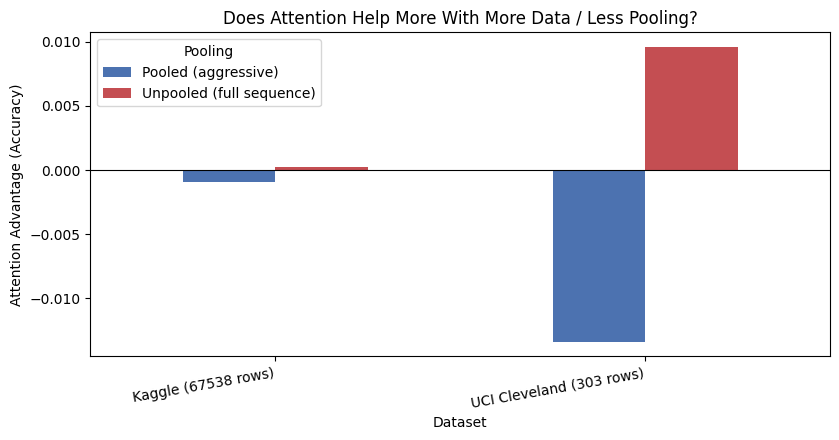

In [22]:
pivot = grid_df.pivot(index="Dataset", columns="Pooling", values="Attention Advantage (Acc)")
ax = pivot.plot(kind="bar", figsize=(8.5, 4.5), color=["#4C72B0", "#C44E52"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Attention Advantage (Accuracy)")
ax.set_title("Does Attention Help More With More Data / Less Pooling?")
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.savefig("attention_advantage_grid.png", dpi=300)
plt.show()

## 11. Statistical Significance: Is Attention's Difference Real?

The CV tables in Sections 6.7/7.6 show attention roughly tied with (UCI) or slightly behind
(both datasets) the no-attention model, but those means are being compared against fairly
large per-fold standard deviations. This section runs attention and no-attention on the
**exact same CV folds** (paired by construction, since both use the same `StratifiedKFold`
with a fixed seed) and tests whether the per-fold differences are large relative to their
own variance - a paired t-test and the non-parametric Wilcoxon signed-rank test, which
doesn't assume the differences are normally distributed (safer with only 5-10 folds).

In [23]:
from scipy import stats

def paired_cv_compare(X_data, y_data, n_splits=10, epochs=60):
    """Runs attention vs. no-attention on the SAME fold splits and returns
    paired per-fold accuracy/AUC lists for a significance test."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    X_np, y_np = X_data.reset_index(drop=True), y_data.reset_index(drop=True)
    use_imputation = X_data.isna().any().any()

    acc_att, acc_noatt, auc_att, auc_noatt = [], [], [], []

    for tr_idx, va_idx in skf.split(X_np, y_np):
        X_tr, X_va = X_np.iloc[tr_idx], X_np.iloc[va_idx]
        y_tr, y_va = y_np.iloc[tr_idx], y_np.iloc[va_idx]

        if use_imputation:
            imp = KNNImputer(n_neighbors=5)
            X_tr_i, X_va_i = imp.fit_transform(X_tr), imp.transform(X_va)
        else:
            X_tr_i, X_va_i = X_tr.values, X_va.values
        sc = StandardScaler()
        X_tr_s, X_va_s = sc.fit_transform(X_tr_i), sc.transform(X_va_i)
        X_tr_r, y_tr_r = SMOTE(random_state=SEED).fit_resample(X_tr_s, y_tr)
        train_loader, test_loader, nf = make_loaders(X_tr_r, y_tr_r, X_va_s, y_va)

        for model_cls, acc_list, auc_list in [
            (CNN_BiLSTM_Attention, acc_att, auc_att),
            (CNN_BiLSTM_NoAttention, acc_noatt, auc_noatt),
        ]:
            m = model_cls(num_features=nf).to(device)
            opt = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
            crit = nn.BCEWithLogitsLoss()
            for _ in range(epochs):
                run_epoch(m, train_loader, crit, opt)
            m.eval()
            probs_l, trues_l = [], []
            with torch.no_grad():
                for xb, yb in test_loader:
                    p, _ = m(xb.to(device))
                    probs_l.append(torch.sigmoid(p).cpu().numpy())
                    trues_l.append(yb.numpy())
            probs = np.concatenate(probs_l).ravel()
            trues = np.concatenate(trues_l).ravel()
            preds = (probs >= 0.5).astype(int)
            acc_list.append(accuracy_score(trues, preds))
            auc_list.append(roc_auc_score(trues, probs) if len(np.unique(trues)) > 1 else float("nan"))

    return {
        "acc_attention": acc_att, "acc_no_attention": acc_noatt,
        "auc_attention": auc_att, "auc_no_attention": auc_noatt,
    }


def report_significance(name, a, b, metric_label):
    a, b = np.array(a), np.array(b)
    diffs = a - b
    t_stat, t_p = stats.ttest_rel(a, b)
    try:
        w_stat, w_p = stats.wilcoxon(a, b)
    except ValueError:
        w_stat, w_p = float("nan"), float("nan")  # e.g. all diffs are zero
    print(f"[{name}] {metric_label}: mean diff (attn - no_attn) = {diffs.mean():+.4f} "
          f"(std {diffs.std():.4f})")
    print(f"    paired t-test:      t={t_stat:.3f}, p={t_p:.4f}")
    print(f"    Wilcoxon signed-rank: W={w_stat:.3f}, p={w_p:.4f}")
    print(f"    -> {'SIGNIFICANT' if min(t_p, w_p) < 0.05 else 'not significant'} at alpha=0.05\n")
    return {"metric": metric_label, "dataset": name, "mean_diff": diffs.mean(),
            "t_p": t_p, "wilcoxon_p": w_p}


sig_results = []

print("=== UCI Cleveland ===")
uci_paired = paired_cv_compare(X_uci, y_uci, n_splits=10, epochs=60)
sig_results.append(report_significance("UCI", uci_paired["acc_attention"], uci_paired["acc_no_attention"], "Accuracy"))
sig_results.append(report_significance("UCI", uci_paired["auc_attention"], uci_paired["auc_no_attention"], "AUC"))

print("=== Kaggle ===")
kaggle_paired = paired_cv_compare(X_kaggle, y_kaggle, n_splits=5, epochs=15)
sig_results.append(report_significance("Kaggle", kaggle_paired["acc_attention"], kaggle_paired["acc_no_attention"], "Accuracy"))
sig_results.append(report_significance("Kaggle", kaggle_paired["auc_attention"], kaggle_paired["auc_no_attention"], "AUC"))

sig_df = pd.DataFrame(sig_results)
sig_df.to_csv("attention_significance_results.csv", index=False)
sig_df

=== UCI Cleveland ===
[UCI] Accuracy: mean diff (attn - no_attn) = -0.0003 (std 0.0630)
    paired t-test:      t=-0.015, p=0.9881
    Wilcoxon signed-rank: W=18.000, p=0.6172
    -> not significant at alpha=0.05

[UCI] AUC: mean diff (attn - no_attn) = +0.0122 (std 0.0338)
    paired t-test:      t=1.083, p=0.3068
    Wilcoxon signed-rank: W=16.500, p=0.2871
    -> not significant at alpha=0.05

=== Kaggle ===
[Kaggle] Accuracy: mean diff (attn - no_attn) = -0.0012 (std 0.0035)
    paired t-test:      t=-0.696, p=0.5248
    Wilcoxon signed-rank: W=5.000, p=0.6250
    -> not significant at alpha=0.05

[Kaggle] AUC: mean diff (attn - no_attn) = -0.0004 (std 0.0007)
    paired t-test:      t=-1.274, p=0.2717
    Wilcoxon signed-rank: W=4.000, p=0.4375
    -> not significant at alpha=0.05



,metric,dataset,mean_diff,t_p,wilcoxon_p
0,Accuracy,UCI,-0.000323,0.988073,0.617188
1,AUC,UCI,0.012223,0.306820,0.287109
2,Accuracy,Kaggle,-0.001214,0.524775,0.625000
3,AUC,Kaggle,-0.000424,0.271722,0.437500


**How to report this:** cite the p-values from `sig_df` directly, e.g. *"the accuracy
difference between the attention and non-attention variants was not statistically
significant (paired t-test, p = X.XX; Wilcoxon signed-rank, p = X.XX)."* If either dataset
does come out significant, report the mean difference and effect direction explicitly rather
than just the p-value — with only 5-10 folds, statistical significance and practical
significance (a fraction of a percent) can diverge.

## 11b. Is the Pooled-vs-Unpooled Attention Difference Real?

Section 9 found that on UCI, unpooled attention beat pooled attention by +0.96pp accuracy /
+1.26pp AUC - but that came from a single CV run per configuration, and UCI's fold-to-fold
accuracy std has been ~6pp elsewhere in this notebook. This section runs pooled-attention and
unpooled-attention on the **same CV folds** (paired by construction) and tests whether that
gap is large relative to its own fold-to-fold variance, the same way Section 11 tested
attention vs. no-attention.

In [24]:
def paired_pooling_compare(X_data, y_data, n_splits=10, epochs=60):
    """Runs CNN_BiLSTM_Attention with use_pooling=True vs. use_pooling=False on the
    SAME fold splits, returning paired per-fold accuracy/AUC lists."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    X_np, y_np = X_data.reset_index(drop=True), y_data.reset_index(drop=True)
    use_imputation = X_data.isna().any().any()

    acc_pooled, acc_unpooled, auc_pooled, auc_unpooled = [], [], [], []

    for tr_idx, va_idx in skf.split(X_np, y_np):
        X_tr, X_va = X_np.iloc[tr_idx], X_np.iloc[va_idx]
        y_tr, y_va = y_np.iloc[tr_idx], y_np.iloc[va_idx]

        if use_imputation:
            imp = KNNImputer(n_neighbors=5)
            X_tr_i, X_va_i = imp.fit_transform(X_tr), imp.transform(X_va)
        else:
            X_tr_i, X_va_i = X_tr.values, X_va.values
        sc = StandardScaler()
        X_tr_s, X_va_s = sc.fit_transform(X_tr_i), sc.transform(X_va_i)
        X_tr_r, y_tr_r = SMOTE(random_state=SEED).fit_resample(X_tr_s, y_tr)
        train_loader, test_loader, nf = make_loaders(X_tr_r, y_tr_r, X_va_s, y_va)

        for use_pool, acc_list, auc_list in [
            (True, acc_pooled, auc_pooled),
            (False, acc_unpooled, auc_unpooled),
        ]:
            m = CNN_BiLSTM_Attention(num_features=nf, use_pooling=use_pool).to(device)
            opt = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
            crit = nn.BCEWithLogitsLoss()
            for _ in range(epochs):
                run_epoch(m, train_loader, crit, opt)
            m.eval()
            probs_l, trues_l = [], []
            with torch.no_grad():
                for xb, yb in test_loader:
                    p, _ = m(xb.to(device))
                    probs_l.append(torch.sigmoid(p).cpu().numpy())
                    trues_l.append(yb.numpy())
            probs = np.concatenate(probs_l).ravel()
            trues = np.concatenate(trues_l).ravel()
            preds = (probs >= 0.5).astype(int)
            acc_list.append(accuracy_score(trues, preds))
            auc_list.append(roc_auc_score(trues, probs) if len(np.unique(trues)) > 1 else float("nan"))

    return {
        "acc_pooled": acc_pooled, "acc_unpooled": acc_unpooled,
        "auc_pooled": auc_pooled, "auc_unpooled": auc_unpooled,
    }


pooling_sig_results = []

print("=== UCI Cleveland: pooled vs. unpooled attention ===")
uci_pool_paired = paired_pooling_compare(X_uci, y_uci, n_splits=10, epochs=60)
pooling_sig_results.append(report_significance(
    "UCI", uci_pool_paired["acc_unpooled"], uci_pool_paired["acc_pooled"], "Accuracy (unpooled - pooled)"
))
pooling_sig_results.append(report_significance(
    "UCI", uci_pool_paired["auc_unpooled"], uci_pool_paired["auc_pooled"], "AUC (unpooled - pooled)"
))

print("=== Kaggle: pooled vs. unpooled attention ===")
kaggle_pool_paired = paired_pooling_compare(X_kaggle, y_kaggle, n_splits=5, epochs=15)
pooling_sig_results.append(report_significance(
    "Kaggle", kaggle_pool_paired["acc_unpooled"], kaggle_pool_paired["acc_pooled"], "Accuracy (unpooled - pooled)"
))
pooling_sig_results.append(report_significance(
    "Kaggle", kaggle_pool_paired["auc_unpooled"], kaggle_pool_paired["auc_pooled"], "AUC (unpooled - pooled)"
))

pooling_sig_df = pd.DataFrame(pooling_sig_results)
pooling_sig_df.to_csv("pooling_significance_results.csv", index=False)
pooling_sig_df

=== UCI Cleveland: pooled vs. unpooled attention ===
[UCI] Accuracy (unpooled - pooled): mean diff (attn - no_attn) = -0.0033 (std 0.0472)
    paired t-test:      t=-0.212, p=0.8368
    Wilcoxon signed-rank: W=12.000, p=0.8125
    -> not significant at alpha=0.05

[UCI] AUC (unpooled - pooled): mean diff (attn - no_attn) = -0.0053 (std 0.0138)
    paired t-test:      t=-1.152, p=0.2789
    Wilcoxon signed-rank: W=22.000, p=0.6270
    -> not significant at alpha=0.05

=== Kaggle: pooled vs. unpooled attention ===
[Kaggle] Accuracy (unpooled - pooled): mean diff (attn - no_attn) = -0.0010 (std 0.0016)
    paired t-test:      t=-1.231, p=0.2857
    Wilcoxon signed-rank: W=4.000, p=0.4375
    -> not significant at alpha=0.05

[Kaggle] AUC (unpooled - pooled): mean diff (attn - no_attn) = -0.0002 (std 0.0014)
    paired t-test:      t=-0.339, p=0.7519
    Wilcoxon signed-rank: W=6.000, p=0.8125
    -> not significant at alpha=0.05



,metric,dataset,mean_diff,t_p,wilcoxon_p
0,Accuracy (unpooled - pooled),UCI,-0.003333,0.836776,0.812500
1,AUC (unpooled - pooled),UCI,-0.005303,0.278931,0.626953
2,Accuracy (unpooled - pooled),Kaggle,-0.000977,0.285698,0.437500
3,AUC (unpooled - pooled),Kaggle,-0.000242,0.751895,0.812500


**Note:** this reuses `report_significance()` from Section 11, so run that section's cell
first if you're executing top-to-bottom from a fresh kernel (it's defined there).

**How to report this:** if `pooling_sig_df` shows p < 0.05 for UCI accuracy/AUC, you have a
statistically defensible claim that removing pooling measurably helps attention on the small
dataset. If it doesn't reach significance, report the Section 9 pooling-grid numbers as a
"suggestive but not statistically confirmed" trend in the Discussion, rather than a firm result
- that's still an honest and useful thing to report, it just needs the right hedge language.

## 12. Attention Entropy: Is Attention Actually Selective?

The attention-weight heatmaps (Sections 6.6/7.5) suggested a visual pattern: on UCI, nearly
every patient's heaviest weight lands on the same pooled position, which looks like a fixed
positional prior rather than genuine per-patient selectivity. This section quantifies that
with the **entropy** of each patient's attention distribution.

- Entropy is maximized (= log(seq_len)) when attention is perfectly uniform (i.e. not
  selecting anything in particular).
- Entropy is low when attention is sharply peaked on one or two positions.
- **Normalized entropy** (entropy / max possible entropy) is reported on a 0-1 scale so the
  two datasets, which have different pooled sequence lengths, are comparable.

Low normalized entropy alone isn't necessarily bad (a model could legitimately learn that
one feature position matters most for every patient) - but combined with the heatmap pattern,
consistently low entropy AND the same position winning for every patient together support the
"positional collapse" explanation for why attention doesn't improve accuracy: it isn't doing
patient-specific reasoning.

In [25]:
def attention_entropy_stats(model, test_loader, label):
    model.eval()
    all_attn = []
    with torch.no_grad():
        for xb, yb in test_loader:
            _, attn = model(xb.to(device))
            if attn is not None:
                all_attn.append(attn.cpu().numpy())
    if not all_attn:
        print(f"[{label}] Model has no attention weights to analyze.")
        return None

    attn_all = np.concatenate(all_attn).squeeze(-1)  # (n_samples, seq_len)
    seq_len = attn_all.shape[1]
    eps = 1e-12
    entropy_per_sample = -np.sum(attn_all * np.log(attn_all + eps), axis=1)
    max_entropy = np.log(seq_len)
    normalized_entropy = entropy_per_sample / max_entropy

    # How often is the same position the argmax across all patients? (a sign of a fixed
    # positional prior rather than patient-specific selection)
    top_positions = attn_all.argmax(axis=1)
    most_common_position, most_common_count = np.unique(top_positions, return_counts=True)
    dominant_position = most_common_position[np.argmax(most_common_count)]
    dominant_frac = most_common_count.max() / len(top_positions)

    print(f"[{label}] seq_len={seq_len}  mean normalized entropy={normalized_entropy.mean():.3f} "
          f"(std {normalized_entropy.std():.3f})")
    print(f"[{label}] most-attended position across patients: {dominant_position} "
          f"({dominant_frac*100:.1f}% of patients have their argmax here)")

    return {
        "dataset": label, "seq_len": seq_len,
        "mean_normalized_entropy": normalized_entropy.mean(),
        "std_normalized_entropy": normalized_entropy.std(),
        "dominant_position": int(dominant_position),
        "dominant_position_frac": dominant_frac,
    }


entropy_results = []
r = attention_entropy_stats(model_u, test_loader_u, "UCI")
if r: entropy_results.append(r)
r = attention_entropy_stats(model_k, test_loader_k, "Kaggle")
if r: entropy_results.append(r)

entropy_df = pd.DataFrame(entropy_results)
entropy_df.to_csv("attention_entropy_results.csv", index=False)
entropy_df

[UCI] seq_len=7  mean normalized entropy=0.978 (std 0.015)
[UCI] most-attended position across patients: 6 (73.8% of patients have their argmax here)
[Kaggle] seq_len=6  mean normalized entropy=0.842 (std 0.069)
[Kaggle] most-attended position across patients: 0 (62.1% of patients have their argmax here)


,dataset,seq_len,mean_normalized_entropy,std_normalized_entropy,dominant_position,dominant_position_frac
0,UCI,7,0.977626,0.015116,6,0.737705
1,Kaggle,6,0.841553,0.069368,0,0.621261


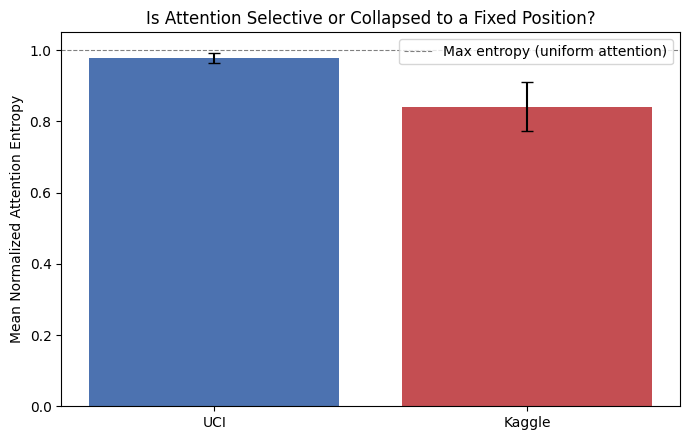

In [26]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(entropy_df["dataset"], entropy_df["mean_normalized_entropy"],
       yerr=entropy_df["std_normalized_entropy"], capsize=4, color=["#4C72B0", "#C44E52"])
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Max entropy (uniform attention)")
ax.set_ylabel("Mean Normalized Attention Entropy")
ax.set_title("Is Attention Selective or Collapsed to a Fixed Position?")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig("attention_entropy_comparison.png", dpi=300)
plt.show()

**How to report this:** low normalized entropy (well below 1.0) combined with a high
`dominant_position_frac` (most patients sharing the same argmax) is direct quantitative
support for the qualitative heatmap observation — cite both numbers together, e.g.
*"attention weights collapsed toward a single pooled position for X% of patients (mean
normalized entropy = Y), suggesting the mechanism learned a near-fixed positional prior
rather than patient-specific feature selection, which is consistent with its lack of
measurable accuracy benefit (Section 11)."*

## 13. Summary

- The earlier single-seed CV cells are retained for exploratory/reference purposes.
- The **final paper numbers must come from Section 14 (`final_5seed_results/`)** after the five independent seeds have completed.
- Report `publication_cv_table_mean_sd.csv` as the headline repeated-CV table.
- Report `proposed_model_holdout_5seed_summary.csv` separately as the repeated held-out test result for the proposed model.
- Report `paired_repeated_5seed_significance.csv` for the conservative five-seed statistical comparisons.
- Report `proposed_model_holdout_5seed_entropy.csv` only as an exploratory entropy analysis, with appropriate caution.


# 14. FINAL 5-SEED REPEATED EXPERIMENTS FOR THE PAPER

**Purpose.** This section is the reproducible final rerun used for the paper's headline statistics.

The experiment uses five independent seeds:
`42, 52, 62, 72, 82`.

For each seed and dataset:

1. A stratified 80/20 split is created; the 20% hold-out test set is never used for model selection.
2. For outer cross-validation, the outer evaluation fold is kept untouched.
3. Inside each outer training fold, a stratified validation split is used for early stopping and learning-rate scheduling.
4. Imputation and scaling are fit only on the inner training partition; SMOTE is applied only to that inner training partition.
5. The outer fold is evaluated only after training.
6. The same seed controls Python/NumPy/PyTorch/scikit-learn/SMOTE and DataLoader shuffling.

Run this section after the earlier data-loading/model-definition cells. The files written here are the **final sources for the paper's repeated-run tables**.


In [ ]:
# Reproducible repeated-run configuration
import random
from pathlib import Path

FINAL_SEEDS = [42, 52, 62, 72, 82]  # five independent seeds
INNER_VAL_SIZE = 0.10                # 10% of each outer-training fold
OUTPUT_DIR = Path("final_5seed_results")
OUTPUT_DIR.mkdir(exist_ok=True)

FINAL_DATASET_SETTINGS = {
    "Kaggle": {"X": X_kaggle, "y": y_kaggle, "n_splits": 5, "epochs": 15, "patience": 5},
    "UCI": {"X": X_uci, "y": y_uci, "n_splits": 10, "epochs": 60, "patience": 10},
}

FINAL_MODEL_CLASSES = {
    "Random Forest": RandomForestClassifier,
    "1D-CNN only": CNNOnly,
    "CNN-BiLSTM": CNN_BiLSTM_NoAttention,
    "CNN-BiLSTM-Attention": CNN_BiLSTM_Attention,
}

def set_all_seeds(seed: int) -> None:
    """Set all relevant RNGs before every independent run."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Deterministic kernels improve reproducibility. May reduce GPU speed.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def make_seeded_loader(X_arr, y_arr, batch_size=BATCH_SIZE, shuffle=False, seed=42):
    Xt, yt = to_tensors(X_arr, y_arr)
    ds = TensorDataset(Xt, yt)
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator if shuffle else None,
    ), Xt.shape[2]


In [ ]:
def preprocess_outer_fold(X_tr, X_outer_val, y_tr, y_outer_val, seed,
                          validation_size=INNER_VAL_SIZE, use_imputation=None):
    """
    Create an inner train/validation split inside an outer training fold.
    All preprocessing is fit only on the inner training partition.
    The outer evaluation fold remains untouched until final evaluation.
    """
    X_tr = X_tr.reset_index(drop=True)
    y_tr = y_tr.reset_index(drop=True)
    X_outer_val = X_outer_val.reset_index(drop=True)
    y_outer_val = y_outer_val.reset_index(drop=True)

    X_inner_tr, X_inner_val, y_inner_tr, y_inner_val = train_test_split(
        X_tr, y_tr,
        test_size=validation_size,
        random_state=seed,
        stratify=y_tr
    )

    if use_imputation is None:
        use_imputation = X_tr.isna().any().any()

    if use_imputation:
        imp = KNNImputer(n_neighbors=5)
        X_inner_tr_i = imp.fit_transform(X_inner_tr)
        X_inner_val_i = imp.transform(X_inner_val)
        X_outer_val_i = imp.transform(X_outer_val)
    else:
        X_inner_tr_i = X_inner_tr.values
        X_inner_val_i = X_inner_val.values
        X_outer_val_i = X_outer_val.values

    scaler = StandardScaler()
    X_inner_tr_s = scaler.fit_transform(X_inner_tr_i)
    X_inner_val_s = scaler.transform(X_inner_val_i)
    X_outer_val_s = scaler.transform(X_outer_val_i)

    X_inner_tr_r, y_inner_tr_r = SMOTE(random_state=seed).fit_resample(
        X_inner_tr_s, y_inner_tr
    )

    return (
        X_inner_tr_r, y_inner_tr_r,
        X_inner_val_s, y_inner_val,
        X_outer_val_s, y_outer_val
    )

def train_neural_with_validation(
    model_cls, X_train, y_train, X_val, y_val, num_features,
    seed, epochs, patience_limit, use_pooling=True, label="model"
):
    """Train with a genuine validation set; test/outer fold is not used."""
    set_all_seeds(seed)

    train_loader, _ = make_seeded_loader(
        X_train, y_train, shuffle=True, seed=seed
    )
    val_loader, _ = make_seeded_loader(
        X_val, y_val, shuffle=False, seed=seed
    )

    model = model_cls(
        num_features=num_features,
        use_pooling=use_pooling
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(
        model.parameters(), lr=1e-3, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=5, factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 0

    for epoch in range(1, epochs + 1):
        run_epoch(model, train_loader, criterion, optimizer)
        val_loss, _ = run_epoch(
            model, val_loader, criterion, optimizer=None
        )
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            patience = 0
        else:
            patience += 1

        if patience >= patience_limit:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

def predict_loader(model, loader):
    model.eval()
    probs_all, true_all, attn_all = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            logits, attn = model(xb.to(device))
            probs_all.append(torch.sigmoid(logits).cpu().numpy())
            true_all.append(yb.numpy())
            if attn is not None:
                attn_all.append(attn.cpu().numpy())

    probs = np.concatenate(probs_all).ravel()
    true = np.concatenate(true_all).ravel()
    pred = (probs >= 0.5).astype(int)
    attn = np.concatenate(attn_all).squeeze(-1) if attn_all else None

    metrics = {
        "Accuracy": accuracy_score(true, pred),
        "Precision": precision_score(true, pred, zero_division=0),
        "Recall": recall_score(true, pred, zero_division=0),
        "F1": f1_score(true, pred, zero_division=0),
        "AUC": roc_auc_score(true, probs),
    }
    return metrics, true, pred, probs, attn


In [ ]:
def repeated_cv_evaluate(
    X, y, model_name, model_cls, n_splits, epochs, patience_limit,
    seeds=FINAL_SEEDS, use_pooling=True, label_prefix=""
):
    """
    Repeated outer CV with independent seeds.
    Neural models use an inner validation split for early stopping.
    Random Forest is fit on the complete outer-training fold.
    Returns fold-level records and summary mean/std.
    """
    all_rows = []
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    for seed in seeds:
        set_all_seeds(seed)
        skf = StratifiedKFold(
            n_splits=n_splits, shuffle=True, random_state=seed
        )

        print(f"\n=== {label_prefix}{model_name} | seed={seed} ===")

        for fold, (outer_tr_idx, outer_val_idx) in enumerate(
            skf.split(X, y), start=1
        ):
            X_outer_tr = X.iloc[outer_tr_idx].copy()
            X_outer_val = X.iloc[outer_val_idx].copy()
            y_outer_tr = y.iloc[outer_tr_idx].copy()
            y_outer_val = y.iloc[outer_val_idx].copy()

            use_imputation = X.isna().any().any()

            if model_cls is RandomForestClassifier:
                # For RF, the outer training fold is the model-fitting partition.
                if use_imputation:
                    imp = KNNImputer(n_neighbors=5)
                    X_tr_i = imp.fit_transform(X_outer_tr)
                    X_val_i = imp.transform(X_outer_val)
                else:
                    X_tr_i = X_outer_tr.values
                    X_val_i = X_outer_val.values

                scaler = StandardScaler()
                X_tr_s = scaler.fit_transform(X_tr_i)
                X_val_s = scaler.transform(X_val_i)

                X_tr_r, y_tr_r = SMOTE(
                    random_state=seed
                ).fit_resample(X_tr_s, y_outer_tr)

                rf = RandomForestClassifier(
                    n_estimators=300,
                    random_state=seed,
                    n_jobs=-1
                )
                rf.fit(X_tr_r, y_tr_r)
                probs = rf.predict_proba(X_val_s)[:, 1]
                true = y_outer_val.to_numpy()
                pred = (probs >= 0.5).astype(int)

                metrics = {
                    "Accuracy": accuracy_score(true, pred),
                    "Precision": precision_score(true, pred, zero_division=0),
                    "Recall": recall_score(true, pred, zero_division=0),
                    "F1": f1_score(true, pred, zero_division=0),
                    "AUC": roc_auc_score(true, probs),
                }
            else:
                (
                    X_inner_tr, y_inner_tr,
                    X_inner_val, y_inner_val,
                    X_outer_val_s, y_outer_val
                ) = preprocess_outer_fold(
                    X_outer_tr, X_outer_val,
                    y_outer_tr, y_outer_val,
                    seed=seed,
                    validation_size=INNER_VAL_SIZE,
                    use_imputation=use_imputation
                )

                # num_features is unchanged by preprocessing.
                num_features = X_inner_tr.shape[1]

                model = train_neural_with_validation(
                    model_cls,
                    X_inner_tr, y_inner_tr,
                    X_inner_val, y_inner_val,
                    num_features=num_features,
                    seed=seed,
                    epochs=epochs,
                    patience_limit=patience_limit,
                    use_pooling=use_pooling,
                    label=f"{label_prefix}{model_name}-s{seed}-f{fold}"
                )

                outer_loader, _ = make_seeded_loader(
                    X_outer_val_s, y_outer_val,
                    shuffle=False, seed=seed
                )
                metrics, _, _, _, _ = predict_loader(
                    model, outer_loader
                )

            row = {
                "dataset": label_prefix.rstrip("-") or "dataset",
                "model": model_name,
                "seed": seed,
                "fold": fold,
                "pooling": use_pooling,
                **metrics,
            }
            all_rows.append(row)
            print(
                f"fold={fold:02d} | "
                + " | ".join(f"{k}={v:.4f}" for k, v in metrics.items())
            )

    fold_df = pd.DataFrame(all_rows)

    summary = (
        fold_df.groupby(["dataset", "model", "pooling"])
        [["Accuracy", "Precision", "Recall", "F1", "AUC"]]
        .agg(["mean", "std"])
        .reset_index()
    )

    return fold_df, summary


In [ ]:
# RUN 1: Five-seed repeated CV for all primary models
all_cv_fold_results = []
all_cv_summary = []

for dataset_name, cfg in FINAL_DATASET_SETTINGS.items():
    fold_df_ds, summary_ds = [], []

    for model_name, model_cls in FINAL_MODEL_CLASSES.items():
        fold_df, summary = repeated_cv_evaluate(
            cfg["X"], cfg["y"],
            model_name=model_name,
            model_cls=model_cls,
            n_splits=cfg["n_splits"],
            epochs=cfg["epochs"],
            patience_limit=cfg["patience"],
            seeds=FINAL_SEEDS,
            use_pooling=True,
            label_prefix=f"{dataset_name}-"
        )
        fold_df_ds.append(fold_df)
        summary_ds.append(summary)

    ds_fold = pd.concat(fold_df_ds, ignore_index=True)
    ds_summary = pd.concat(summary_ds, ignore_index=True)
    all_cv_fold_results.append(ds_fold)
    all_cv_summary.append(ds_summary)

cv_all_folds = pd.concat(all_cv_fold_results, ignore_index=True)
cv_summary = pd.concat(all_cv_summary, ignore_index=True)

cv_all_folds.to_csv(OUTPUT_DIR / "cv_repeated_5seed_fold_results.csv", index=False)
cv_summary.to_csv(OUTPUT_DIR / "cv_repeated_5seed_summary.csv", index=False)

# Publication-ready wide table: mean ± SD
def format_mean_std(mean, std, digits=4):
    return f"{mean:.{digits}f} $\\pm$ {std:.{digits}f}"

publication_rows = []
for _, row in cv_summary.iterrows():
    publication_rows.append({
        "Dataset": row["dataset"],
        "Model": row["model"],
        "Accuracy": format_mean_std(row[("Accuracy", "mean")], row[("Accuracy", "std")]),
        "Precision": format_mean_std(row[("Precision", "mean")], row[("Precision", "std")]),
        "Recall": format_mean_std(row[("Recall", "mean")], row[("Recall", "std")]),
        "F1": format_mean_std(row[("F1", "mean")], row[("F1", "std")]),
        "AUC": format_mean_std(row[("AUC", "mean")], row[("AUC", "std")]),
    })

publication_cv_table = pd.DataFrame(publication_rows)
publication_cv_table.to_csv(OUTPUT_DIR / "publication_cv_table_mean_sd.csv", index=False)

print("\nSaved:")
print(OUTPUT_DIR / "cv_repeated_5seed_fold_results.csv")
print(OUTPUT_DIR / "cv_repeated_5seed_summary.csv")
print(OUTPUT_DIR / "publication_cv_table_mean_sd.csv")
publication_cv_table


In [ ]:
# RUN 2: Repeated five-seed pooled-vs-unpooled and attention-vs-no-attention comparisons
def repeated_paired_comparison(
    X, y, n_splits, epochs, patience_limit,
    variant="attention", seeds=FINAL_SEEDS, dataset_name="dataset"
):
    rows = []

    for seed in seeds:
        set_all_seeds(seed)
        skf = StratifiedKFold(
            n_splits=n_splits, shuffle=True, random_state=seed
        )
        fold_diffs = []

        for fold, (outer_tr_idx, outer_val_idx) in enumerate(
            skf.split(X, y), start=1
        ):
            X_outer_tr = X.iloc[outer_tr_idx].copy()
            X_outer_val = X.iloc[outer_val_idx].copy()
            y_outer_tr = y.iloc[outer_tr_idx].copy()
            y_outer_val = y.iloc[outer_val_idx].copy()

            use_imputation = X.isna().any().any()

            if use_imputation:
                imp = KNNImputer(n_neighbors=5)
                X_tr_i = imp.fit_transform(X_outer_tr)
                X_val_i = imp.transform(X_outer_val)
            else:
                X_tr_i = X_outer_tr.values
                X_val_i = X_outer_val.values

            # Create the same inner split for both paired variants.
            X_inner_tr, X_inner_val, y_inner_tr, y_inner_val = train_test_split(
                X_outer_tr, y_outer_tr,
                test_size=INNER_VAL_SIZE,
                random_state=seed,
                stratify=y_outer_tr
            )

            if use_imputation:
                imp2 = KNNImputer(n_neighbors=5)
                X_inner_tr_i = imp2.fit_transform(X_inner_tr)
                X_inner_val_i = imp2.transform(X_inner_val)
                X_outer_val_i = imp2.transform(X_outer_val)
            else:
                X_inner_tr_i = X_inner_tr.values
                X_inner_val_i = X_inner_val.values
                X_outer_val_i = X_outer_val.values

            scaler = StandardScaler()
            X_inner_tr_s = scaler.fit_transform(X_inner_tr_i)
            X_inner_val_s = scaler.transform(X_inner_val_i)
            X_outer_val_s = scaler.transform(X_outer_val_i)

            X_inner_tr_r, y_inner_tr_r = SMOTE(
                random_state=seed
            ).fit_resample(X_inner_tr_s, y_inner_tr)

            if variant == "attention":
                model_specs = [
                    ("attention", CNN_BiLSTM_Attention, True),
                    ("no_attention", CNN_BiLSTM_NoAttention, True),
                ]
            elif variant == "pooling":
                model_specs = [
                    ("unpooled", CNN_BiLSTM_Attention, False),
                    ("pooled", CNN_BiLSTM_Attention, True),
                ]
            else:
                raise ValueError("variant must be 'attention' or 'pooling'")

            fold_metrics = {}
            for tag, ctor, use_pooling in model_specs:
                model = train_neural_with_validation(
                    ctor,
                    X_inner_tr_r, y_inner_tr_r,
                    X_inner_val_s, y_inner_val,
                    num_features=X_inner_tr_r.shape[1],
                    seed=seed,
                    epochs=epochs,
                    patience_limit=patience_limit,
                    use_pooling=use_pooling,
                    label=f"{dataset_name}-{tag}-s{seed}-f{fold}"
                )

                outer_loader, _ = make_seeded_loader(
                    X_outer_val_s, y_outer_val,
                    shuffle=False, seed=seed
                )
                metrics, *_ = predict_loader(model, outer_loader)
                fold_metrics[tag] = metrics

            row = {
                "dataset": dataset_name,
                "seed": seed,
                "fold": fold,
            }

            if variant == "attention":
                for metric in ["Accuracy", "AUC"]:
                    row[f"{metric}_attention"] = fold_metrics["attention"][metric]
                    row[f"{metric}_no_attention"] = fold_metrics["no_attention"][metric]
                    row[f"{metric}_diff"] = (
                        fold_metrics["attention"][metric]
                        - fold_metrics["no_attention"][metric]
                    )
            else:
                for metric in ["Accuracy", "AUC"]:
                    row[f"{metric}_unpooled"] = fold_metrics["unpooled"][metric]
                    row[f"{metric}_pooled"] = fold_metrics["pooled"][metric]
                    row[f"{metric}_diff"] = (
                        fold_metrics["unpooled"][metric]
                        - fold_metrics["pooled"][metric]
                    )

            rows.append(row)

    result = pd.DataFrame(rows)
    return result

def repeated_seed_level_significance(result_df, variant):
    """
    Conservative repeated-seed significance:
    first average paired fold differences within each seed, then test
    the five seed-level paired differences (n=5).
    """
    output = []

    for metric in ["Accuracy", "AUC"]:
        diff_col = f"{metric}_diff"
        seed_means = result_df.groupby("seed")[diff_col].mean().to_numpy()

        t_stat, t_p = stats.ttest_1samp(seed_means, 0.0)
        try:
            w_stat, w_p = stats.wilcoxon(seed_means)
        except ValueError:
            w_stat, w_p = np.nan, np.nan

        output.append({
            "variant": variant,
            "metric": metric,
            "n_seeds": len(seed_means),
            "mean_seed_difference": seed_means.mean(),
            "std_seed_difference": seed_means.std(ddof=1),
            "t_stat": t_stat,
            "t_p": t_p,
            "wilcoxon_stat": w_stat,
            "wilcoxon_p": w_p,
        })

    return pd.DataFrame(output)

paired_results = []
paired_significance = []

for dataset_name, cfg in FINAL_DATASET_SETTINGS.items():
    attn_df = repeated_paired_comparison(
        cfg["X"], cfg["y"], cfg["n_splits"], cfg["epochs"], cfg["patience"],
        variant="attention", seeds=FINAL_SEEDS, dataset_name=dataset_name
    )
    attn_sig = repeated_seed_level_significance(attn_df, "Attention vs No-Attention")
    attn_df["comparison"] = "Attention vs No-Attention"
    paired_results.append(attn_df)
    paired_significance.append(
        attn_sig.assign(dataset=dataset_name)
    )

    pool_df = repeated_paired_comparison(
        cfg["X"], cfg["y"], cfg["n_splits"], cfg["epochs"], cfg["patience"],
        variant="pooling", seeds=FINAL_SEEDS, dataset_name=dataset_name
    )
    pool_sig = repeated_seed_level_significance(pool_df, "Unpooled vs Pooled")
    pool_df["comparison"] = "Unpooled vs Pooled"
    paired_results.append(pool_df)
    paired_significance.append(
        pool_sig.assign(dataset=dataset_name)
    )

repeated_paired_df = pd.concat(paired_results, ignore_index=True)
repeated_significance_df = pd.concat(paired_significance, ignore_index=True)

repeated_paired_df.to_csv(
    OUTPUT_DIR / "paired_repeated_5seed_fold_results.csv", index=False
)
repeated_significance_df.to_csv(
    OUTPUT_DIR / "paired_repeated_5seed_significance.csv", index=False
)

print("\nRepeated-seed paired significance:")
display(repeated_significance_df)


In [ ]:
# RUN 3: Final held-out 80/20 test performance for the proposed model across five seeds
def repeated_holdout_proposed(X, y, dataset_name, epochs, patience, seeds=FINAL_SEEDS):
    rows = []
    entropy_rows = []

    for seed in seeds:
        set_all_seeds(seed)

        X_dev, X_test, y_dev, y_test = train_test_split(
            X.reset_index(drop=True),
            y.reset_index(drop=True),
            test_size=0.20,
            random_state=seed,
            stratify=y
        )

        (
            X_train, X_val, y_train, y_val,
            X_test_s, y_test
        ) = preprocess_outer_fold(
            X_dev, X_test, y_dev, y_test,
            seed=seed,
            validation_size=INNER_VAL_SIZE,
            use_imputation=X.isna().any().any()
        )

        model = train_neural_with_validation(
            CNN_BiLSTM_Attention,
            X_train, y_train,
            X_val, y_val,
            num_features=X_train.shape[1],
            seed=seed,
            epochs=epochs,
            patience_limit=patience,
            use_pooling=True,
            label=f"{dataset_name}-final-s{seed}"
        )

        test_loader, _ = make_seeded_loader(
            X_test_s, y_test, shuffle=False, seed=seed
        )
        metrics, true, pred, probs, attn = predict_loader(model, test_loader)

        row = {
            "Dataset": dataset_name,
            "Seed": seed,
            "N_test": len(y_test),
            **metrics,
        }
        rows.append(row)

        if attn is not None:
            entropy = -np.sum(
                attn * np.log(attn + 1e-12), axis=1
            )
            norm_entropy = entropy / np.log(attn.shape[1])
            top_positions = attn.argmax(axis=1)
            _, counts = np.unique(
                top_positions, return_counts=True
            )
            entropy_rows.append({
                "Dataset": dataset_name,
                "Seed": seed,
                "Sequence_Length": attn.shape[1],
                "Mean_Normalized_Entropy": norm_entropy.mean(),
                "Std_Normalized_Entropy": norm_entropy.std(ddof=1),
                "Dominant_Position": int(
                    np.bincount(top_positions).argmax()
                ),
                "Dominant_Position_Fraction": counts.max() / len(top_positions),
            })

    result_df = pd.DataFrame(rows)
    entropy_df = pd.DataFrame(entropy_rows)

    return result_df, entropy_df

holdout_results = []
holdout_entropy = []

for dataset_name, cfg in FINAL_DATASET_SETTINGS.items():
    res_df, ent_df = repeated_holdout_proposed(
        cfg["X"], cfg["y"],
        dataset_name=dataset_name,
        epochs=cfg["epochs"],
        patience=cfg["patience"],
        seeds=FINAL_SEEDS
    )
    holdout_results.append(res_df)
    holdout_entropy.append(ent_df)

holdout_df = pd.concat(holdout_results, ignore_index=True)
holdout_entropy_df = pd.concat(holdout_entropy, ignore_index=True)

holdout_df.to_csv(
    OUTPUT_DIR / "proposed_model_holdout_5seed_results.csv", index=False
)
holdout_entropy_df.to_csv(
    OUTPUT_DIR / "proposed_model_holdout_5seed_entropy.csv", index=False
)

holdout_summary = (
    holdout_df.groupby("Dataset")
    [["Accuracy", "Precision", "Recall", "F1", "AUC"]]
    .agg(["mean", "std"])
    .reset_index()
)
holdout_summary.to_csv(
    OUTPUT_DIR / "proposed_model_holdout_5seed_summary.csv", index=False
)

print("Final five-seed held-out summary:")
display(holdout_summary)


In [ ]:
# RUN 4: Final sanity checks and metadata for the paper
metadata = {
    "seeds": FINAL_SEEDS,
    "n_seeds": len(FINAL_SEEDS),
    "inner_validation_fraction": INNER_VAL_SIZE,
    "datasets": {
        "Kaggle": {
            "outer_folds": FINAL_DATASET_SETTINGS["Kaggle"]["n_splits"],
            "epochs": FINAL_DATASET_SETTINGS["Kaggle"]["epochs"],
            "patience": FINAL_DATASET_SETTINGS["Kaggle"]["patience"],
        },
        "UCI": {
            "outer_folds": FINAL_DATASET_SETTINGS["UCI"]["n_splits"],
            "epochs": FINAL_DATASET_SETTINGS["UCI"]["epochs"],
            "patience": FINAL_DATASET_SETTINGS["UCI"]["patience"],
        },
    },
    "test_set_used_for_early_stopping": False,
    "test_set_used_for_learning_rate_scheduling": False,
    "smote_applied_only_to_training_partition": True,
    "preprocessing_fit_only_on_training_partition": True,
}

with open(OUTPUT_DIR / "experiment_metadata.json", "w", encoding="utf-8") as f:
    import json
    json.dump(metadata, f, indent=2)

assert metadata["n_seeds"] >= 5
assert metadata["test_set_used_for_early_stopping"] is False
assert metadata["test_set_used_for_learning_rate_scheduling"] is False
assert metadata["smote_applied_only_to_training_partition"] is True
assert metadata["preprocessing_fit_only_on_training_partition"] is True

print("FINAL 5-SEED EXPERIMENT CONFIGURATION")
print(json.dumps(metadata, indent=2))
print(f"\nResults directory: {OUTPUT_DIR.resolve()}")


## Final reporting rule

For the IEEE paper, use the outputs from `final_5seed_results/`:

- `publication_cv_table_mean_sd.csv` — headline repeated-CV table (Accuracy, Precision, Recall, F1, AUC).
- `proposed_model_holdout_5seed_summary.csv` — repeated held-out test summary for the proposed model.
- `paired_repeated_5seed_significance.csv` — conservative five-seed paired significance analysis.
- `paired_repeated_5seed_fold_results.csv` — underlying paired fold-level results.
- `proposed_model_holdout_5seed_entropy.csv` — entropy variability across independent seeds.
- `experiment_metadata.json` — exact reproducibility settings.

**Do not overwrite the old paper tables with the old single-seed values.** After this section is run successfully, replace the old results in the manuscript with these files' values.
